![Logos](img/logos.png)

# 3.1 VIIRS satellite vs MONARCH dust forecast comparison: Processing with MAPIES

#### Objective

The objective of this notebook is to pre-process VIIRS satellite dust data with MAPIES, so that it may be subsequently compared with MONARCH forecast data.

## Introduction to VIIRS and the Deep Blue aerosol project

The Visible Infrared Imaging Radiometer Suite (VIIRS) is an instrument that observes and collects global satellite observations that span the visible and infrared wavelengths across land, ocean, and atmosphere [1]. VIIRS is one of five instruments onboard the Suomi National Polar-orbiting Partnership (NPP) and NOAA-20 satellites.


The Deep Blue (DB) AOD retrieval algorithm family includes two main algorithms: Deep Blue (DB, used over land) and Satellite Ocean Aerosol Retrieval (SOAR, used over oceans) [2]. DB uses blue wavelength channels where surface reflectance is low and stable, allowing retrieval of AOD over bright surfaces (for example: deserts, rocks, and urban areas) [2]. Over vegetated surfaces where surface reflecrance changes more rapidly over time, surface reflectance is estimated dynamically using known spectral ratios [2]. SOAR performs a multispectral iterative least-squares fit to retrieve AOD at 550 nm, fine-mode fraction of AOD at 550nm, and best-fitting aerosol type. Other information, such as spectral AOD and Ångström exponent, is derived from these parameters [2]. The resulting data products have been validated against AERONET and MAN observations [2]. For more information regarding quality flags and data use recommendations, please be sure to check the VIIRS Deep Blue Aerosol User Guide [2].

In our `/data` folder, we have the subfolder `/VIIRS` that contains all observational files, downloaded directly from [EARTHDATA](https://ladsweb.modaps.eosdis.nasa.gov/archive/allData/5200/AERDB_L2_VIIRS_NOAA20/). For our purposes, our data is VIIRS NOAA20 Aerosol DB Level 2 data. Note that the files are organised per day, where each folder is in Julian day format to match file data.

## Introduction to MAPIES

MAPIES (Mapper, Aggregator and Preprocessor for Integration of Earth Observation Satellites) is a Python-based framework whose purpose is the processing, analysis and visualisation of atmospheric satellite data. It is a tool developed at BSC, which under our available Version 0.2.0 can process both VIIRS and TROPOMI data.

In the following exercise, we will learn more about MAPIES's functionalities and how we can use it to process dust satellite observations.

## Initialising MAPIES

To use MAPIES in a Jupyter Notebook, we need to import its Python path and import the `VIIRS` class.

In [1]:
import sys
sys.path.append("/home/jupyter-tvintimi/atarri/tools/mapies") # path where you have the MAPIES tool

In [3]:
%matplotlib inline
from mapies.viirs import VIIRS
import numpy as np
import time

Next, we create the VIIRS object with the following format:

~~~
c = VIIRS(start_date, end_date, outdir=outdir, indir=indir, grid_repr)
~~~

where:

<table>
<tr>
<th>Parameter</th>
<th>Description</th>
<th>Example</th>
</tr>
<tr>
<td>

`start_date`
</td>
<td>Starting time of the analysis in string format. Should be written as YYYYMMDDhhmm.</td>
<td>"202201011200"</td>
</tr>
<tr>
<td>

`end_date`
</td>
<td>End time of the analysis in string format. Should be written as YYYYMMDDhhmm.</td>
<td>"202201011200"</td>
</tr>
<tr>
<td>

`outdir`
</td>
<td>Save directory for the processed outputs.</td>
<td>

</td>
</tr>
<tr>
<td>

`indir`
</td>
<td>Directory containing input satellite data.</td>
<td>

</td>
</tr>
<tr>
<td>

`grid_rep`
</td>
<td>

Sets the grid type/domain to be used for subsequent processing and saving of output data. These grid parameters are set in the `satellite_config.yaml` file. By default, the user can set the following options:

* `rotated`: Uses rotated latitude and longitude, has a has a regional domain at 0.1 resolution.
* `bdrc`: Used by the BDRC. Uses rotated latitude and longitude, has a regional domain at 0.1 resolution.
* `regular`: Uses regular latitude and longitude, global domain at 0.2 resolution.
* `cams`: Used by CAMS. Uses rotated latitude and longitude, has a NAMEE domain at 0.2 resolution.
* `global`: Uses regular latitude and longitude, global domain at 0.1 resolution.

You can add more customised grids in the `/mapies/config/satellite_config.yaml` file.
</td>
<td>

</td>
</tr>
</table>

For our case, we will focus on the days where the event is at its peak. Hence, we will set our parameters as follows:

In [4]:
start_date = "202503040000"
end_date = "202503080000"

In [5]:
outdir = "../plot_outputs" # output path where your plots and files are stored
indir = '/shared/data/VIIRS' # directory where your VIIRS data is located

In [6]:
c = VIIRS(start_date, end_date, outdir=outdir, indir=indir, grid_repr="regular")

Enter resolution or number of grid cells


## Processing

Now we can call our processing functions. First we need to run `gather_nc_files()` to select our file paths.

In [7]:
c.gather_nc_files()

Now, we are able to process our observations. MAPIES contains two methods for this: `process_avg_data` and `process_lazy_data`.

#### process_avg_data()

The `process_avg_data` function computes averages and the number of valid observations. It uses the following parameters:

~~~
process_avg_data(frequency_avg, min_num_obs, save=False, apply_qa=True, save_format="flattened", geospatial_crop)
~~~

<table>
<tr>
<th>Parameter</th>
<th>Description</th>
<th>Example</th>
</tr>
<tr>
<td>

`frequency_avg`
</td>
<td>

Frequency at which the average should be calculated. This frequency can be:

* Custom alphanumerical: Requires an integer n followed by either the letters H (hours), D (days) or M (months) for a custom calculation at said frequency.
* Preset: Requires either the letters `D` (takes one day = 24H), `W` (takes one week = 24H \* 7), `M` (takes one month = 24H \* 30) or `Y` (takes one year = 24H \* 356), or it can be set to `None` (takes a single average of all input data).
</td>
<td>

frequency_avg = 15D

frequency_avg = M frequency_avg = None
</td>
</tr>
<tr>
<td>

`min_num_obs`
</td>
<td>Sets the minimum number of observations in a grid cell to proceed with the analysis. Requires an integer number as input.</td>
<td>min_num_obs=10</td>
</tr>

<tr>
<td>

`apply_qa`

</td>
<td>

Applies the quality assurance flags set in the `satellite_config.yaml` file. It can be set to:

* `True` (default)
* `False`
</td>
<td>

</td>
</tr>

<tr>
<td>

`save`

(optional parameter)
</td>
<td>

Determines whether the averaged data is saved to a .nc file. It can be:

* `True`
* `False` (default)
</td>
<td>

</td>
</tr>

<tr>
<td>

`save_format`

(optional parameter)
</td>
<td>

Format for which to save processed observational data. Requires `save=True`. There are two options:

* `flattened` : (default) Saves the data in a flattened array.
* `gridded`: Saves the data in a gridded array.
</td>
<td>

</td>
</tr>

<tr>
<td>

`geospatial_crop`

(optional parameter)
</td>
<td>Utilises two sets of coordinates to form a geospatial frame that limits data processing to inside this region.</td>
<td>geospatial_crop = [[43.8, -9.3], [36, 3.3]]</td>
</tr>
</table>



#### process_lazy_data()

The `process_lazy_data` method returns a total concatenatation of the input satellite data without making any computations, applying QA flags and reformatting output data to MAPIES standards. It uses the following parameters:

~~~
process_lazy_data(apply_qa=True, save=False, geospatial_crop)
~~~

<table>
<tr>
<th>Parameter</th>
<th>Description</th>
<th>Example</th>
</tr>
<tr>
<td>

`apply_qa`

</td>
<td>

Applies the quality assurance flags set in the `satellite_config.yaml` file. It can be set to:

* `True` (default)
* `False`
</td>
<td>

</td>
</tr>
    
<tr>
<td>

`save`

(optional parameter)
</td>
<td>

Determines whether the averaged data is saved to a .nc file. It can be:

* `True`: saves data as a flattened array.
* `False` (default)
</td>
<td>

</td>
</tr>
<tr>
<td>

`geospatial_crop`

(optional parameter)
</td>
<td>Utilises two sets of coordinates to form a geospatial frame that limits data processing to inside this region.</td>
<td>geospatial_crop=[[43.8, -9.3], [36, 3.3]]</td>
</tr>

</table>

### Processing our VIIRS datasets

As we are exclusively interested in analysing the area affected by the dust event (the Eastern Mediterranean), we will create a geospatial crop:

In [8]:
geospatial_crop = [[20, 45], [30, 40]]

Now, we will apply the processing functions. For the purposes of this comparison, we will focus on creating daily averages for the entire period and we will save them to .nc format for later use. Hence, we will use the `process_avg_data` method with `frequency_avg='D'` and `save=True`. To match the MONARCH grid, we need to set the save format to `gridded`. 

Finally, we need to ensure we only process data corresponding to our dust event. If we go to our MAPIES folder and look for `/mapies/mapies/config/satellite_config.yaml`, we will find a list of quality configurations used for the processing.

If we check the VIIRS variables, we can see that, as a default, MAPIES is already processing `Aerosol_Optical_Thickness_550_Land_Ocean_Best_Estimate`. Under `qa_variables`, the QA values are already set for processing only dust optical thickness as a default. The .yaml can be changed at any point according to individual needs, but in our case, we will use the default settings with `apply_qa=True`, and run the processing method.

In [9]:
c.process_avg_data(min_num_obs=0,
                   frequency_avg=None,
                   apply_qa=True,
                   save = True,
                   save_format='gridded',
                   geospatial_crop=geospatial_crop
                  )

2026-02-04 10:16:32.385 | INFO     | mapies.util.settings:setup_filters:125 - QA: True
2026-02-04 10:16:32.386 | INFO     | mapies.util.settings:setup_filters:126 - Applying QA flags: {'qa_land': {'qa_name': 'Aerosol_Optical_Thickness_QA_Flag_Land', 'qa_values': [2, 3], 'qa_combined': False}, 'qa_ocean': {'qa_name': 'Aerosol_Optical_Thickness_QA_Flag_Ocean', 'qa_values': [3], 'qa_combined': False}, 'qa_type': {'qa_name': 'Aerosol_Type_Land_Ocean', 'qa_values': [0], 'qa_combined': True}}
2026-02-04 10:16:32.388 | INFO     | mapies.util.settings:setup_filters:130 - Applying Geospatial cropping: [[20, 45], [30, 40]]
2026-02-04 10:16:32.389 | INFO     | mapies.mapies:process_avg_data:103 - Processing data from 2025-03-04 00:00:00 to 2025-03-08 00:00:00, grid: regular, qa: True, geospatial crop: [[20 45]
 [30 40]], total number of files 564
100%|█████████▉| 563/564 [01:19<00:00,  7.09it/s]
2026-02-04 10:17:51.930 | WARNING  | mapies.mapies:process_data_mp:164 - Some files do not have valid 

You will notice that all plotting and processing methods will print out a log of the current state of the processing.

With this method, our MAPIES-processed .nc file has been saved into the `plot_outputs/` folder.

## Plotting

MAPIES contains two plotting methods that may be used with 2D observations: `plot_2D_observations()` and `plot_2D_num_obs()`.

#### plot_2D_observations()

The `plot_2D_observations()` method creates and saves a 2D map plot of the averaged observations. It uses the following parameters:

~~~
plot_2d_observations(filename=None, outdir)
~~~

<table>
<tr>
<th>Parameter</th>
<th>Description</th>
<th>Example</th>
</tr>
<tr>
<td>

`filename`

(optional parameter)

</td>
<td>

Sets a file name for the output plot file. There are two accepted methods for setting the file name:
* `None`: (default) If no file name is set, the output plot is automatically saved in the format `satellite_2D_obs_from_start_to_end.png`. This option always saves the output in a .png format.
* Custom name: A custom name can be selected for the output file in string format. If this option is selected, the file extension needs to be explicitly set. The accepted formats are .png, .jpg and .jpeg.
</td>
<td>
filename="example.png"
</td>
</tr>
    
<tr>
<td>

`outdir`

</td>
<td>

Save directory for the plot output.
</td>
<td>

</td>
</tr>

<tr>
<td>

`display_fig`
(optional)
</td>
<td>

Displays the output plot in a Jupyter Notebook. It has two possible inputs:

* True
* False (default)
</td>
<td>

</td>
</tr>

</table>

#### plot_2D_num_obs()

The `plot_2D_num_obs()` method creates and saves a 2D map plot of the number of available observations per pixel. It uses the following parameters:

~~~
plot_2d_num_obs(filename=None, outdir)
~~~

<table>
<tr>
<th>Parameter</th>
<th>Description</th>
<th>Example</th>
</tr>
<tr>
<td>

`filename`

(optional parameter)

</td>
<td>

Sets a file name for the output plot file. There are two accepted methods for setting the file name:
* `None`: (default) If no file name is set, the output plot is automatically saved in the format `satellite_2D_obs_from_start_to_end.png`. This option always saves the output in a .png format.
* Custom name: A custom name can be selected for the output file in string format. If this option is selected, the file extension needs to be explicitly set. The accepted formats are .png, .jpg and .jpeg.
</td>
<td>
filename="example.png"
</td>
</tr>
    
<tr>
<td>

`outdir`

</td>
<td>

Save directory for the plot output.
</td>
<td>

</td>
</tr>

<tr>
<td>

`display_fig`
(optional)
</td>
<td>

Displays the output plot in a Jupyter Notebook. It has two possible inputs:

* True
* False (default)
</td>
<td>

</td>
</tr>

</table>

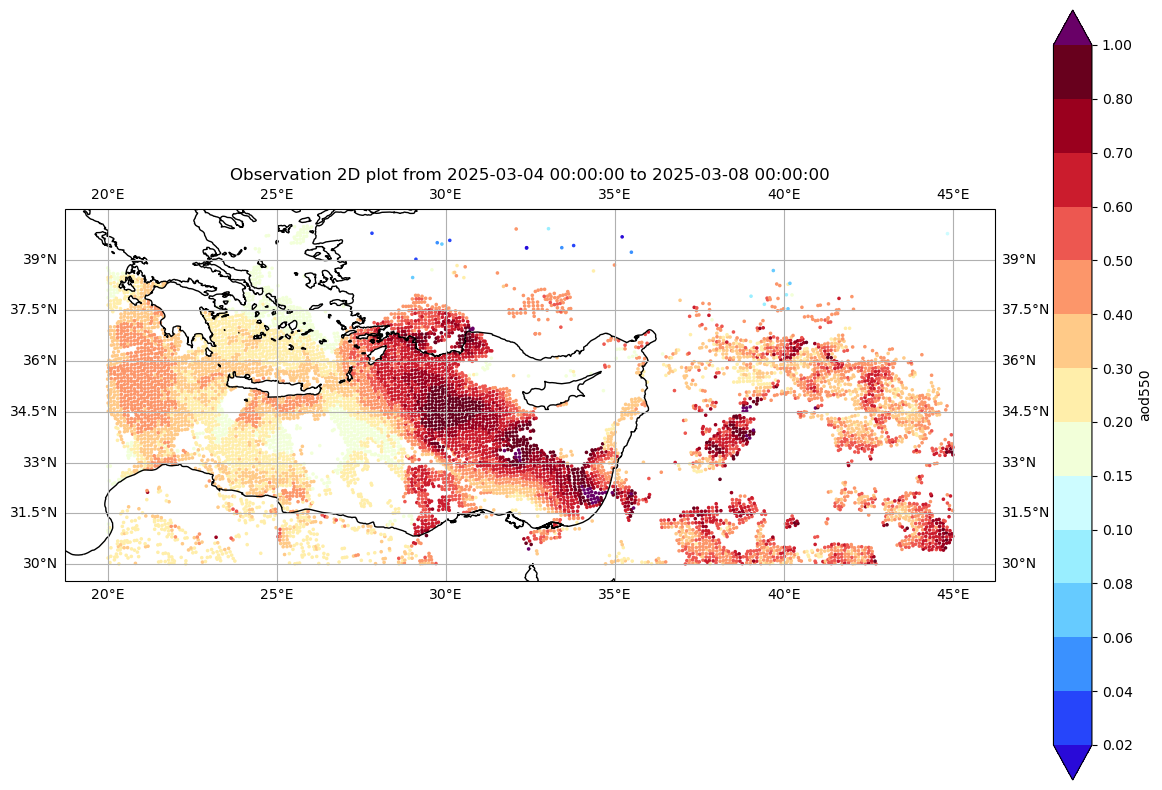

2026-02-04 10:29:02.195 | INFO     | mapies.util.plotting:plot_2D_obs_custom:98 - Saved plot: ../plot_outputs/viirs_2D_obs_from_202503040000_to_202503080000.png


In [10]:
c.plot_2D_observations(outdir=outdir,
                       display_fig=True
                      )

Likewise, we can use `plot_2D_num_obs()` to plot the number of valid 2D observations across the specified area.

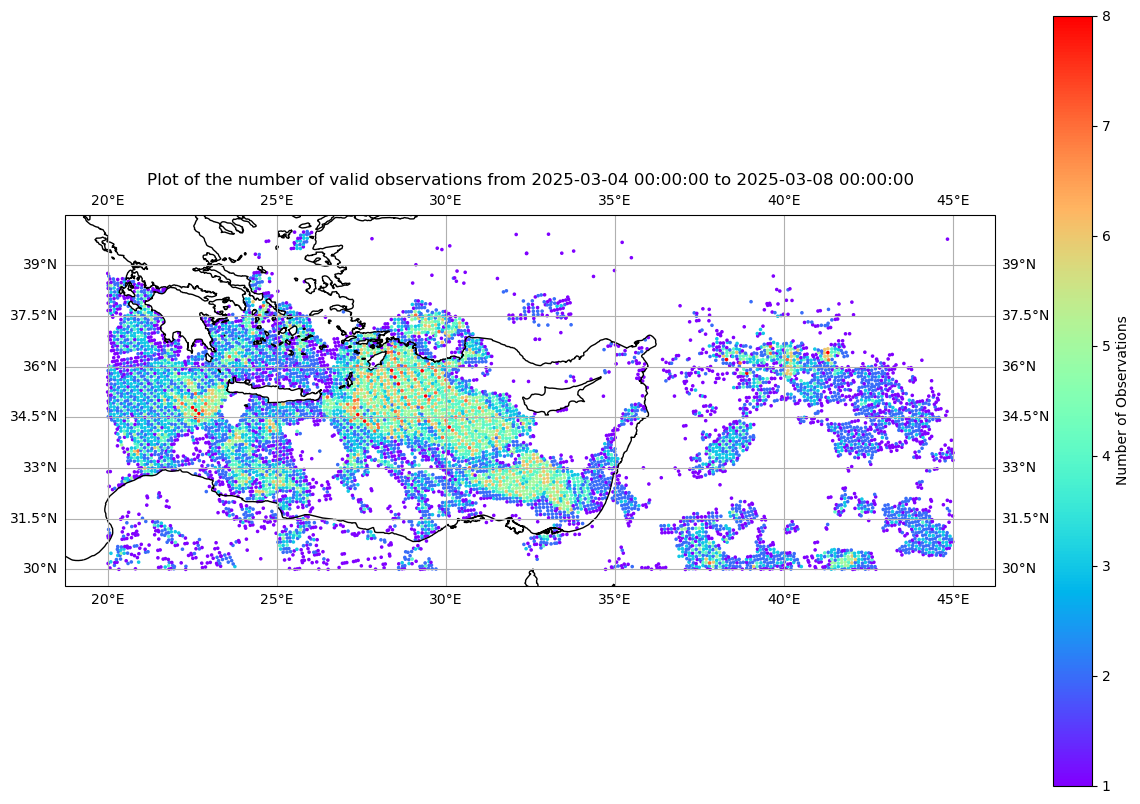

2026-02-04 10:29:21.098 | INFO     | mapies.util.plotting:plot_2D_num_obs_custom:160 - Saved plot: ../plot_outputs/viirs_2D_obs_count_from_202503040000_to_202503080000.png


In [11]:
c.plot_2D_num_obs(outdir=outdir,
                  display_fig=True
                 )

## References and further reading

[1] VIIRS information: https://ladsweb.modaps.eosdis.nasa.gov/missions-and-measurements/viirs/

[2] We thank the Deep Blue science team (https://deepblue.gsfc.nasa.gov) for the VIIRS Deep Blue aerosol data record.

VIIRS data downloaded from [EARTHDATA](https://ladsweb.modaps.eosdis.nasa.gov/archive/allData/5200/AERDB_L2_VIIRS_NOAA20/)

MAPIES is an Python framework developed at BSC-CNS. For more information, please contact [Calum Meikle](mailto:calum.meikle@bsc.es) and [Carlotta Gilè](mailto:carlotta.gile@bsc.es).

<table style="width:100%;">
    <tr>
                <td style="text-align: center;"><a href="VT3-3-MPLNET_MONARCH_daily_avg.ipynb" style="font-size: 18px;">⬅ Previous</a></td>
        <td style="text-align: center;"><a href="VT3-5-VIIRS_MONARCH_comparison.ipynb" style="font-size: 18px;">Next ➡</a></td>
    </tr
</table>